In [ ]:

رابط البيانات/ ـ https://www.kaggle.com/datasets/abdallaellaithy/330k-arabic-sentiment-reviews

تم تحميل البيانات بنجاح.

--- معلومات عامة عن البيانات ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330000 entries, 0 to 329999
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   label    330000 non-null  int64 
 1   content  330000 non-null  object
dtypes: int64(1), object(1)
memory usage: 5.0+ MB

--- القيم الفارغة في كل عمود ---
label      0
content    0
dtype: int64

--- التحقق من القيم الفريدة في عمود 'label' ---
[1 0]

--- استعراض أول 5 صفوف من البيانات ---
   label                                            content
0      1  النعال المريحة: أرتدي هذه النعال كثيرًا!فهي دا...
1      1  منتج جميل ، خدمة سيئة: لقد اشتريت زوجًا من الن...
2      1  جيد للأشياء الصغيرة: هذا يعمل بشكل جيد لالتقاط...
3      0  واهية للغاية: flimsyif للغاية ، فأنت تشتريه ، ...
4      1  Pop for Girls and Girly Boys ، والأشخاص الذين ...


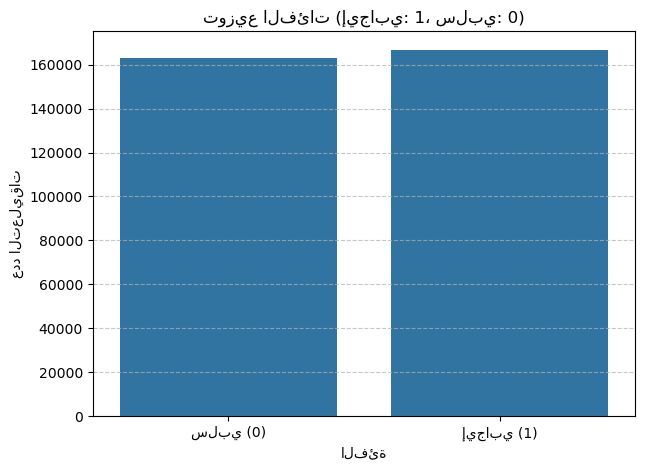


متوسط طول التعليقات: 64.70 كلمة
الوسيط لطول التعليقات: 58.00 كلمة

--- 5 أمثلة من التعليقات الإيجابية (label = 1) ---
التعليق: أكياس ذات جودة أرشفة غير مكلفة: أنا أستخدم هذه الأكياس لأرشيف المجلات ولكن أيضًا من المطبوعات الفضائ... (الطول: 62 كلمة)
التعليق: مجموعة جميلة حقًا ولكن ...: المجموعة لطيفة حقًا - الرقائق ثقيلة والحالة جميلة.لكن الدرج الموجود داخل... (الطول: 39 كلمة)
التعليق: راديو صغير لطيف: أحب أنه يمكنك الحصول على مستوى الصوت ، عندما يكون ذلك في الإعداد الأدنى ، فهو ليس ب... (الطول: 68 كلمة)
التعليق: طابعة صور رائعة: ليست طابعة الصور رائعة فقط للصور الملونة ، ولكنها توفر أيضًا طباعة نصية ذات جودة با... (الطول: 53 كلمة)
التعليق: دع توقعاتك تذهب: ما لم أكن أعرفه عندما أحضرت هذا كان هذا هو نفس المؤلف الذي كتب الكتاب الفظيع الذي ي... (الطول: 49 كلمة)

--- 5 أمثلة من التعليقات السلبية (label = 0) ---
التعليق: التخلي عن الدقة للسرعة ، لا يستحق كل هذا العناء: يحاول مقياس الحرارة أن يكون "سريعًا" ويعطي قراءات خ... (الطول: 70 كلمة)
التعليق: نصف القصة في ثلاث مرات المجلد: إذا كنت يائ

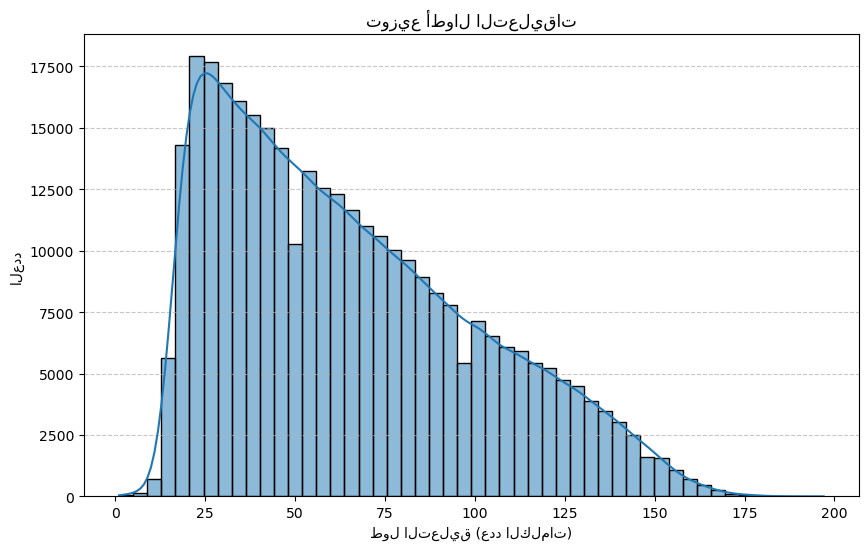

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# تحميل مجموعة البيانات
try:
    df = pd.read_csv('arabic_sentiment_reviews.csv')
except FileNotFoundError:
    print("خطأ: ملف 'arabic_sentiment_reviews.csv' غير موجود. يرجى التأكد من وجود الملف في نفس مسار هذا الكود.")
    exit()

print("تم تحميل البيانات بنجاح.")
print("\n--- معلومات عامة عن البيانات ---")
df.info()

print("\n--- القيم الفارغة في كل عمود ---")
print(df.isnull().sum())

# التحقق من وجود قيم غير منطقية (على افتراض أن 'label' يجب أن تكون 0 أو 1)
print("\n--- التحقق من القيم الفريدة في عمود 'label' ---")
print(df['label'].unique())
if not set(df['label'].unique()).issubset({0, 1}):
    print("تحذير: عمود 'label' يحتوي على قيم غير 0 أو 1. قد تحتاج إلى تنظيفها.")

print("\n--- استعراض أول 5 صفوف من البيانات ---")
print(df.head())

# استعراض توزيع الفئات (label)
plt.figure(figsize=(7, 5))
sns.countplot(x='label', data=df)
plt.title('توزيع الفئات (إيجابي: 1، سلبي: 0)')
plt.xlabel('الفئة')
plt.ylabel('عدد التعليقات')
plt.xticks(ticks=[0, 1], labels=['سلبي (0)', 'إيجابي (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# حساب طول كل تعليق
df['text_length'] = df['content'].apply(lambda x: len(str(x).split()))

# حساب المتوسط والوسيط لطول التعليقات
mean_length = df['text_length'].mean()
median_length = df['text_length'].median()

print(f"\nمتوسط طول التعليقات: {mean_length:.2f} كلمة")
print(f"الوسيط لطول التعليقات: {median_length:.2f} كلمة")

# عرض أمثلة من كل فئة
print("\n--- 5 أمثلة من التعليقات الإيجابية (label = 1) ---")
for i, row in df[df['label'] == 1].sample(min(5, len(df[df['label'] == 1]))).iterrows():
    print(f"التعليق: {row['content'][:100]}... (الطول: {row['text_length']} كلمة)")

print("\n--- 5 أمثلة من التعليقات السلبية (label = 0) ---")
for i, row in df[df['label'] == 0].sample(min(5, len(df[df['label'] == 0]))).iterrows():
    print(f"التعليق: {row['content'][:100]}... (الطول: {row['text_length']} كلمة)")

# رسم بياني لتوزيع أطوال التعليقات
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title('توزيع أطوال التعليقات')
plt.xlabel('طول التعليق (عدد الكلمات)')
plt.ylabel('العدد')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [2]:
import re
import unicodedata
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split

# حل بديل لتحميل بيانات nltk
try:
    nltk.data.find('corpora/stopwords')
    nltk.data.find('tokenizers/punkt')
except LookupError:
    try:
        nltk.download('stopwords', quiet=True)
        nltk.download('punkt', quiet=True)
    except:
        print("تحذير: تعذر تحميل بيانات nltk. استخدام قائمة توقف بديلة.")
        ARABIC_STOPWORDS = set(['في', 'من', 'إلى', 'على', 'أن', 'ما', 'هذا', 'هذه', 'ذلك', 'هو', 'هي', 'كان', 'يكون', 'مع', 'لا', 'لكن', 'أو', 'إن', 'إذا', 'قد', 'حتى', 'بين', 'عند', 'بعض', 'كل', 'لم', 'نحن', 'هنا', 'هناك', 'و', 'ف', 'ثم', 'أي', 'أيضا', 'كما', 'ب', 'ل', 'ك', 'س', 'ي', 'ت', 'أ', 'عن', 'مع', 'ضد', 'فوق', 'تحت', 'قبل', 'بعد', 'دون', 'حول', 'خلال', 'عبر', 'حيث', 'إذ', 'أمام', 'خلف', 'فى', 'منذ', 'حتى', 'إلا', 'غير', 'كل', 'أي', 'إن', 'أن', 'إلخ', 'إلى', 'عليها', 'عليه', 'علي', 'عندما', 'عند', 'عن', 'فيها', 'فيه', 'هو', 'هي', 'هذا', 'هذه', 'ذلك', 'هؤلاء', 'هنا', 'هناك', 'و', 'ف', 'ثم', 'أو', 'أيضا', 'كذلك', 'كما', 'لما', 'لم', 'لن', 'ما', 'من', 'نحن', 'هو', 'هي', 'هم', 'هن', 'هنا', 'هناك', 'و', 'يا', 'قد', 'لا', 'لكن', 'لقد', 'لو', 'ما', 'مع', 'ماذا', 'متى', 'نحن', 'هل', 'و', 'يا', 'إذا', 'إن', 'إذ', 'إلا', 'لكن', 'لأن', 'لذا', 'لذلك', 'لقد', 'لو', 'ما', 'متى', 'مع', 'ماذا', 'نحن', 'هل', 'و', 'يا', 'إذا', 'إن'])

# 1. أخذ عينة عشوائية من البيانات الأصلية
print(f"حجم البيانات الأصلي: {len(df)} تعليق")
SAMPLE_SIZE = 50000

# أخذ عينة عشوائية مع الحفاظ على التوازن
if 'label' in df.columns:
    # استخدام train_test_split لأخذ عينة طبقية بسيطة
    df_sample, _ = train_test_split(
        df,
        train_size=SAMPLE_SIZE,
        stratify=df['label'],
        random_state=42
    )
else:
    # إذا لم يكن هناك عمود تسمية، نأخذ عينة عشوائية بسيطة
    df_sample = df.sample(SAMPLE_SIZE, random_state=42)

print(f"حجم العينة النهائي: {len(df_sample)} تعليق")

def clean_arabic_text(text):
    """
    دالة متطورة لتنظيف ومعالجة النصوص العربية بكفاءة
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    
    # 1. إزالة التشكيل (الحركات) باستخدام unicode normalization
    text = unicodedata.normalize('NFKD', text)
    text = ''.join([c for c in text if not unicodedata.combining(c)])
    
    # 2. إزالة التكرار الزائد في الحروف (أكثر من حرفين متتاليين)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    
    # 3. إزالة كل ما ليس حرفاً عربياً أو مسافة
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    
    # 4. توحيد الحروف العربية
    replacements = {
        'إ': 'ا', 'أ': 'ا', 'آ': 'ا', 'ة': 'ه', 
        'ى': 'ي', 'ؤ': 'ء', 'ئ': 'ء', 'گ': 'ك',
        'ڤ': 'ف', 'چ': 'ج', 'ڨ': 'ق', 'ڭ': 'ن'
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    
    # 5. إزالة المسافات الزائدة
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 6. إزالة الكلمات الشائعة والقصيرة
    try:
        stop_words = set(stopwords.words('arabic'))
    except:
        stop_words = ARABIC_STOPWORDS if 'ARABIC_STOPWORDS' in globals() else set()
    
    tokens = word_tokenize(text) if text else []
    
    # فلترة الكلمات (إزالة التوقف والكلمات القصيرة)
    filtered_tokens = [
        word for word in tokens 
        if word not in stop_words and len(word) > 1
    ]
    
    return ' '.join(filtered_tokens)

# 2. تطبيق التنظيف على العينة فقط
print("\n--- بدء تنظيف ومعالجة النصوص للعينة ---")
df_processed = df_sample.copy()
df_processed['cleaned_content'] = df_processed['content'].apply(clean_arabic_text)
print("تمت عملية تنظيف ومعالجة النصوص بنجاح.")

# 3. عرض أمثلة قبل وبعد التنظيف للعينة
print("\n--- أمثلة قبل وبعد التنظيف (من العينة) ---")
sample_count = min(5, len(df_processed))
for i in range(sample_count):
    original = df_processed['content'].iloc[i]
    cleaned = df_processed['cleaned_content'].iloc[i]
    
    orig_preview = original[:70] + ('...' if len(original) > 70 else '')
    clean_preview = cleaned[:70] + ('...' if len(cleaned) > 70 else '')
    
    print(f"الأصلي ({len(original)} حرف): {orig_preview}")
    print(f"المنظف ({len(cleaned)} حرف): {clean_preview}\n")

# 4. تقسيم بيانات العينة
if 'cleaned_content' in df_processed.columns and 'label' in df_processed.columns:
    X = df_processed['cleaned_content']
    y = df_processed['label']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42, 
        stratify=y
    )

    print(f"\nحجم مجموعة التدريب: {len(X_train)} عينة")
    print(f"حجم مجموعة الاختبار: {len(X_test)} عينة")
    
    if not y_train.empty:
        print(f"توزيع الفئات في التدريب:\n{y_train.value_counts(normalize=True)}")
    if not y_test.empty:
        print(f"توزيع الفئات في الاختبار:\n{y_test.value_counts(normalize=True)}")
else:
    print("\nخطأ: البيانات اللازمة غير موجودة في DataFrame")

حجم البيانات الأصلي: 330000 تعليق
حجم العينة النهائي: 50000 تعليق

--- بدء تنظيف ومعالجة النصوص للعينة ---
تمت عملية تنظيف ومعالجة النصوص بنجاح.

--- أمثلة قبل وبعد التنظيف (من العينة) ---
الأصلي (275 حرف): الأفضل: أمر العديد من هذه بأختي .. احتجزها ......... الآن يجب أن تطلب ...
المنظف (195 حرف): الافضل امر العديد باختي احتجزها الان يجب ان تطلب المزيدفهي مريحه ودافي...

الأصلي (287 حرف): ليس ما كنت أتوقعه: لقد استأجرت هذا الفيلم بشكل رئيسي بسبب كولن فيرث.حس...
المنظف (234 حرف): كنت اتوقعه لقد استاجرت الفيلم بشكل رييسي بسبب كولن فيرثحسنا يفعل الفيل...

الأصلي (362 حرف): السعادة المجنونة المرحة: على الرغم من أن هذه المجموعة تفوت في بعض الأح...
المنظف (279 حرف): السعاده المجنونه المرحه علي الرغم ان المجموعه تفوت الاحيان الاتجاه الا...

الأصلي (357 حرف): رائع!: هذا هو الكتاب الذي جعلني مدمن مخدرات على موارد Nora في التشويق!...
المنظف (289 حرف): رايع الكتاب جعلني مدمن مخدرات علي موارد التشويققبل قرات فقط رواياتها ا...

الأصلي (204 حرف): يا له من كتاب تغيير الحياة: هذا الكتاب أمر لا بد منه 


--- تدريب وتقييم النماذج وتخزين الأفضل ---


===== تقييم باستخدام CountVectorizer =====

  تدريب وتقييم: Naive Bayes
    الدقة (Accuracy): 0.8482
    الدقة الإيجابية (Precision): 0.8482
    الاستدعاء (Recall): 0.8482
    مقياس F1 (F1-Score): 0.8482
    زمن التدريب: 0.05 ثانية
    زمن التنبؤ: 0.01 ثانية

  تدريب وتقييم: Logistic Regression
    الدقة (Accuracy): 0.8453
    الدقة الإيجابية (Precision): 0.8454
    الاستدعاء (Recall): 0.8453
    مقياس F1 (F1-Score): 0.8453
    زمن التدريب: 4.46 ثانية
    زمن التنبؤ: 0.00 ثانية

  أفضل نموذج لـ CountVectorizer: Naive Bayes بدقة 0.8482
  تم تخزين النموذج في: best_models/best_model_CountVectorizer.joblib


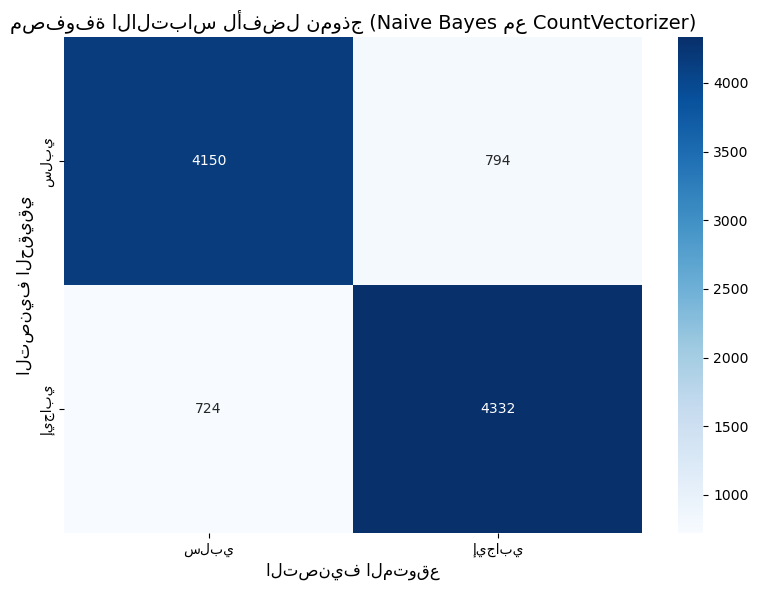



===== تقييم باستخدام TF-IDF =====

  تدريب وتقييم: Naive Bayes
    الدقة (Accuracy): 0.8451
    الدقة الإيجابية (Precision): 0.8452
    الاستدعاء (Recall): 0.8451
    مقياس F1 (F1-Score): 0.8451
    زمن التدريب: 0.03 ثانية
    زمن التنبؤ: 0.00 ثانية

  تدريب وتقييم: Logistic Regression
    الدقة (Accuracy): 0.8635
    الدقة الإيجابية (Precision): 0.8635
    الاستدعاء (Recall): 0.8635
    مقياس F1 (F1-Score): 0.8635
    زمن التدريب: 0.85 ثانية
    زمن التنبؤ: 0.00 ثانية

  أفضل نموذج لـ TF-IDF: Logistic Regression بدقة 0.8635
  تم تخزين النموذج في: best_models/best_model_TF-IDF.joblib


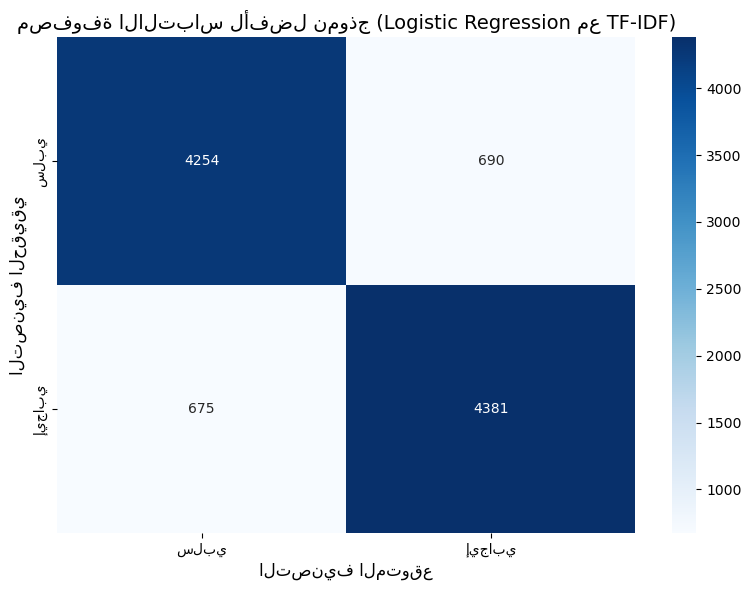


تم حفظ جميع النتائج في ملف CSV


In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pandas as pd

# قائمة لتخزين النتائج
results = []
best_models = {}

print("\n--- تدريب وتقييم النماذج وتخزين الأفضل ---")

for vec_name, (X_train_vec, X_test_vec, vectorizer) in vectorizers.items():
    print(f"\n\n===== تقييم باستخدام {vec_name} =====")
    models = {
        'Naive Bayes': MultinomialNB(),
        'Logistic Regression': LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
    }
    
    best_accuracy = 0
    best_model_name = None
    best_model = None
    
    for model_name, model in models.items():
        print(f"\n  تدريب وتقييم: {model_name}")
        
        # تدريب النموذج
        start_time = time.time()
        model.fit(X_train_vec, y_train)
        train_time = time.time() - start_time
        
        # التنبؤ
        start_pred_time = time.time()
        y_pred = model.predict(X_test_vec)
        pred_time = time.time() - start_pred_time
        
        # حساب المقاييس
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        cm = confusion_matrix(y_test, y_pred)
        
        # التحقق من أفضل دقة
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model_name = model_name
            best_model = model
        
        # حفظ النتائج
        results.append({
            'Vectorizer': vec_name,
            'Model': model_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'Train Time (s)': train_time,
            'Prediction Time (s)': pred_time
        })
        
        # طباعة النتائج
        print(f"    الدقة (Accuracy): {accuracy:.4f}")
        print(f"    الدقة الإيجابية (Precision): {precision:.4f}")
        print(f"    الاستدعاء (Recall): {recall:.4f}")
        print(f"    مقياس F1 (F1-Score): {f1:.4f}")
        print(f"    زمن التدريب: {train_time:.2f} ثانية")
        print(f"    زمن التنبؤ: {pred_time:.2f} ثانية")
    
    # تخزين النموذج الأفضل
    if best_model:
        model_filename = f'best_models/best_model_{vec_name}.joblib'
        joblib.dump(best_model, model_filename)
        print(f"\n  أفضل نموذج لـ {vec_name}: {best_model_name} بدقة {best_accuracy:.4f}")
        print(f"  تم تخزين النموذج في: {model_filename}")
    
    # رسم مصفوفة الالتباس للنموذج الأفضل
    if best_model:
        y_pred_best = best_model.predict(X_test_vec)
        cm_best = confusion_matrix(y_test, y_pred_best)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['سلبي', 'إيجابي'], yticklabels=['سلبي', 'إيجابي'])
        plt.title(f'مصفوفة الالتباس لأفضل نموذج ({best_model_name} مع {vec_name})', fontsize=14)
        plt.xlabel('التصنيف المتوقع', fontsize=12)
        plt.ylabel('التصنيف الحقيقي', fontsize=12)
        plt.tight_layout()
        plt.savefig(f'results/confusion_matrix_best_{vec_name}.png')
        plt.show()

# حفظ جميع النتائج
results_df = pd.DataFrame(results)
results_df.to_csv('results/all_model_performance.csv', index=False, encoding='utf-8-sig')
print("\nتم حفظ جميع النتائج في ملف CSV")


--- ملخص أداء جميع النماذج ---
        Vectorizer                Model  Accuracy  Precision  Recall  \
0  CountVectorizer          Naive Bayes    0.8482   0.848244  0.8482   
1  CountVectorizer  Logistic Regression    0.8453   0.845392  0.8453   
2           TF-IDF          Naive Bayes    0.8451   0.845155  0.8451   
3           TF-IDF  Logistic Regression    0.8635   0.863499  0.8635   

   F1-Score  Train Time (s)  Prediction Time (s)  
0  0.848181        0.053246             0.005981  
1  0.845270        4.455289             0.004643  
2  0.845077        0.027027             0.004080  
3  0.863497        0.847099             0.002993  


--- أفضل النماذج حسب الدقة ---
        Vectorizer                Model  Accuracy  Precision  Recall  \
3           TF-IDF  Logistic Regression    0.8635   0.863499  0.8635   
0  CountVectorizer          Naive Bayes    0.8482   0.848244  0.8482   
1  CountVectorizer  Logistic Regression    0.8453   0.845392  0.8453   
2           TF-IDF          Nai

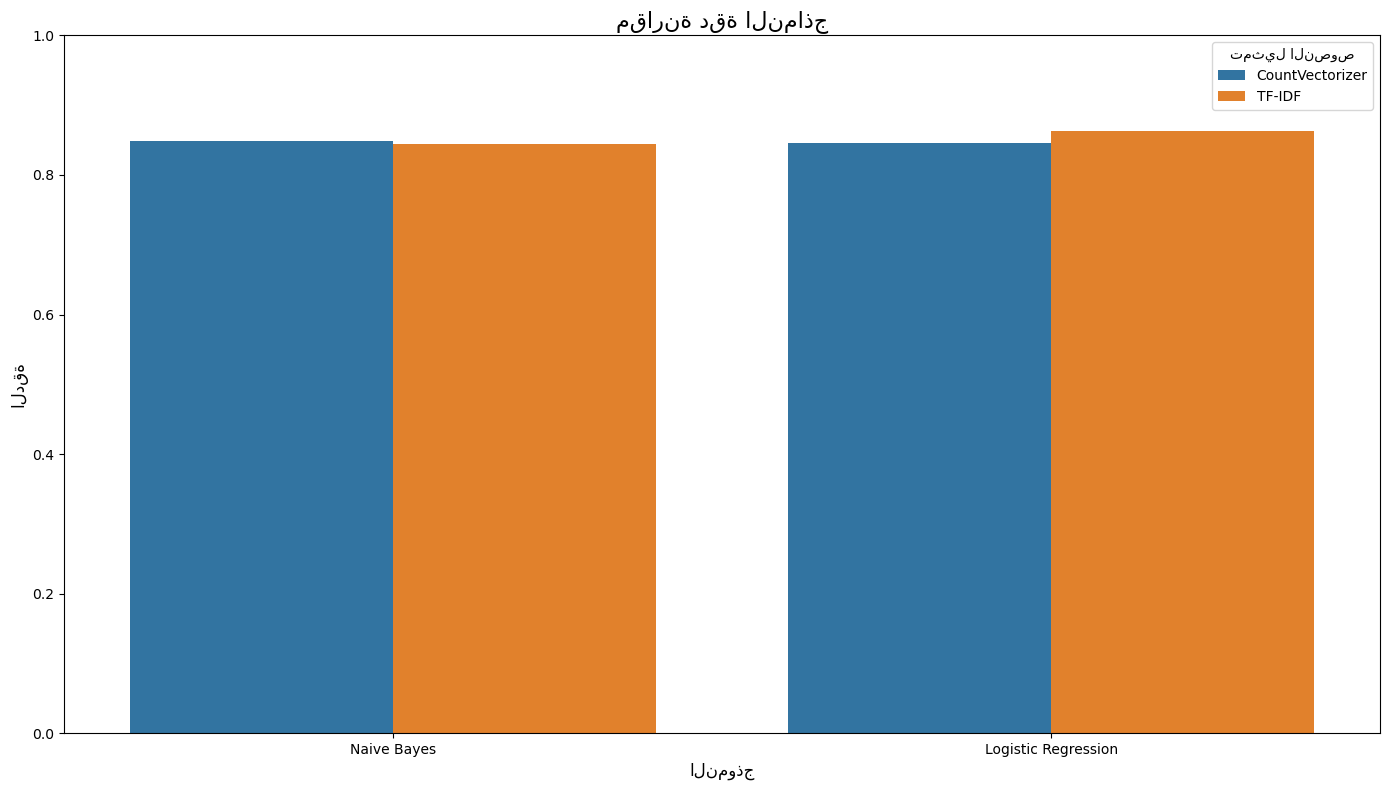

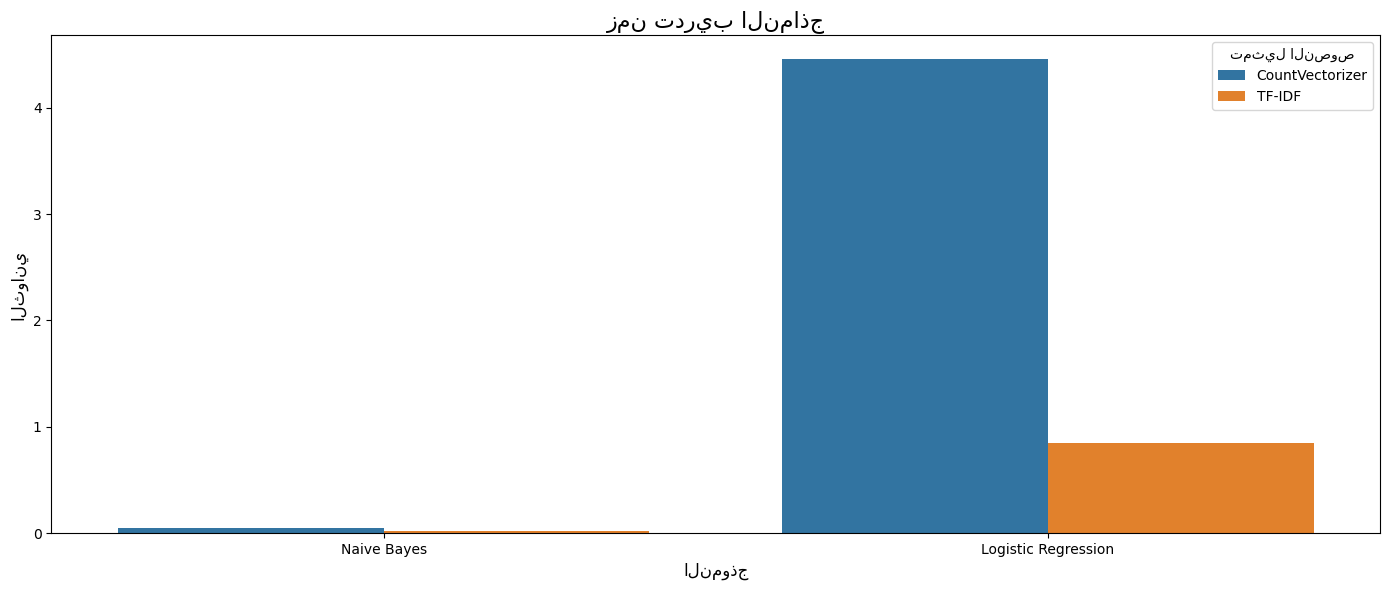


--- النماذج الأفضل المخزنة ---
  - CountVectorizer: best_models/best_model_CountVectorizer.joblib
  - TF-IDF: best_models/best_model_TF-IDF.joblib

--- تم الانتهاء من التدريب والتقييم ---
تم تخزين النماذج الأفضل في مجلد 'best_models'
تم حفظ جميع النتائج في مجلد 'results'


In [15]:
# تحليل النتائج النهائية
print("\n--- ملخص أداء جميع النماذج ---")
print(results_df)

# ترتيب النماذج حسب الدقة
sorted_results = results_df.sort_values(by='Accuracy', ascending=False)

# عرض أفضل النماذج
print("\n\n--- أفضل النماذج حسب الدقة ---")
print(sorted_results.head())

# رسم مقارنة أداء النماذج
plt.figure(figsize=(14, 8))
sns.barplot(data=results_df, x='Model', y='Accuracy', hue='Vectorizer')
plt.title('مقارنة دقة النماذج', fontsize=16)
plt.ylabel('الدقة', fontsize=12)
plt.xlabel('النموذج', fontsize=12)
plt.ylim(0, 1)
plt.legend(title='تمثيل النصوص')
plt.tight_layout()
plt.savefig('results/model_accuracy_comparison.png')
plt.show()

# رسم مقارنة وقت التدريب
plt.figure(figsize=(14, 6))
sns.barplot(data=results_df, x='Model', y='Train Time (s)', hue='Vectorizer')
plt.title('زمن تدريب النماذج', fontsize=16)
plt.ylabel('الثواني', fontsize=12)
plt.xlabel('النموذج', fontsize=12)
plt.legend(title='تمثيل النصوص')
plt.tight_layout()
plt.savefig('results/training_time_comparison.png')
plt.show()

# عرض النماذج الأفضل لكل متجه
print("\n--- النماذج الأفضل المخزنة ---")
for vec_name in vectorizers.keys():
    model_path = f'best_models/best_model_{vec_name}.joblib'
    if os.path.exists(model_path):
        print(f"  - {vec_name}: {model_path}")

print("\n--- تم الانتهاء من التدريب والتقييم ---")
print("تم تخزين النماذج الأفضل في مجلد 'best_models'")
print("تم حفظ جميع النتائج في مجلد 'results'")

In [7]:
# قم بتشغيل هذه الخلية مرة واحدة لتثبيت المكتبات
!pip install gradio

In [9]:
import gradio as gr
import joblib
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import unicodedata  # لإزالة التشكيل

# تحميل موارد NLTK المطلوبة
try:
    nltk.data.find('corpora/stopwords')
except:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except:
    nltk.download('punkt')

# 1. تحميل النموذج والموجه الأفضل (LR مع CountVectorizer)
try:
    # تحميل نموذج Logistic Regression الأفضل مع CountVectorizer
    loaded_model = joblib.load('best_models/best_model_CountVectorizer.joblib')
    
    # تحميل متجه CountVectorizer
    loaded_vectorizer = joblib.load('best_models/count_vectorizer.joblib')
    
    print("تم تحميل النموذج والموجه بنجاح.")
except Exception as e:
    print(f"خطأ في تحميل النموذج أو الموجه: {str(e)}")
    print("يرجى التأكد من وجود ملفات النموذج والموجه في مجلد 'best_models'")
    print("الأسماء المتوقعة:")
    print("- best_models/best_model_CountVectorizer.joblib")
    print("- best_models/count_vectorizer.joblib")
    exit()

# 2. تعريف دالة التنظيف المطابقة لما استخدم في التدريب
def clean_arabic_text(text):
    """
    دالة متطورة لتنظيف ومعالجة النصوص العربية بكفاءة
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    
    # 1. إزالة التشكيل (الحركات) - باستخدام unicode normalization
    text = ''.join([c for c in text if not unicodedata.combining(c)])
    
    # 2. إزالة التكرار الزائد في الحروف
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    
    # 3. إزالة كل ما ليس حرفاً عربياً أو مسافة
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    
    # 4. توحيد الحروف العربية
    replacements = {
        'إ': 'ا', 'أ': 'ا', 'آ': 'ا', 'ة': 'ه', 
        'ى': 'ي', 'ؤ': 'ء', 'ئ': 'ء', 'گ': 'ك',
        'ڤ': 'ف', 'چ': 'ج', 'ڨ': 'ق', 'ڭ': 'ن'
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    
    # 5. إزالة المسافات الزائدة
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 6. إزالة الكلمات الشائعة والقصيرة
    try:
        # استخدام قائمة التوقف من nltk
        stop_words = set(stopwords.words('arabic'))
    except:
        # قائمة توقف بديلة في حالة فشل تحميل nltk
        stop_words = set([
            'في', 'من', 'إلى', 'على', 'أن', 'ما', 'هذا', 'هذه', 'ذلك', 'هو', 'هي', 'كان', 'يكون', 
            'مع', 'لا', 'لكن', 'أو', 'إن', 'إذا', 'قد', 'حتى', 'بين', 'عند', 'بعض', 'كل', 'لم', 'نحن', 
            'هنا', 'هناك', 'و', 'ف', 'ثم', 'أي', 'أيضا', 'كما', 'ب', 'ل', 'ك', 'س', 'ي', 'ت', 'أ', 
            'عن', 'مع', 'ضد', 'فوق', 'تحت', 'قبل', 'بعد', 'دون', 'حول', 'خلال', 'عبر', 'حيث', 'إذ', 
            'أمام', 'خلف', 'فى', 'منذ', 'حتى', 'إلا', 'غير', 'كل', 'أي', 'إن', 'أن', 'إلخ', 'إلى', 
            'عليها', 'عليه', 'علي', 'عندما', 'عند', 'عن', 'فيها', 'فيه', 'هو', 'هي', 'هذا', 'هذه', 
            'ذلك', 'هؤلاء', 'هنا', 'هناك', 'و', 'ف', 'ثم', 'أو', 'أيضا', 'كذلك', 'كما', 'لما', 'لم', 
            'لن', 'ما', 'من', 'نحن', 'هو', 'هي', 'هم', 'هن', 'هنا', 'هناك', 'و', 'يا', 'قد', 'لا', 
            'لكن', 'لقد', 'لو', 'ما', 'مع', 'ماذا', 'متى', 'نحن', 'هل', 'و', 'يا', 'إذا', 'إن', 
            'إذ', 'إلا', 'لكن', 'لأن', 'لذا', 'لذلك', 'لقد', 'لو', 'ما', 'متى', 'مع', 'ماذا', 
            'نحن', 'هل', 'و', 'يا', 'إذا', 'إن'
        ])
    
    tokens = word_tokenize(text) if text else []
    
    # فلترة الكلمات (إزالة التوقف والكلمات القصيرة)
    filtered_tokens = [
        word for word in tokens 
        if word not in stop_words and len(word) > 1
    ]
    
    return ' '.join(filtered_tokens)

# 3. تعريف دالة التنبؤ
def predict_sentiment(comment):
    """
    تتوقع شعور تعليق عربي جديد.
    """
    # تنظيف التعليق
    cleaned_comment = clean_arabic_text(comment)
    
    # تحويل التعليق باستخدام الموجه المحمّل
    comment_vec = loaded_vectorizer.transform([cleaned_comment])
    
    # التنبؤ باستخدام النموذج المحمّل
    prediction = loaded_model.predict(comment_vec)[0]
    prediction_proba = loaded_model.predict_proba(comment_vec)[0]
    
    # تحويل التنبؤ إلى نص قابل للقراءة مع الاحتمالات
    if prediction == 1:
        result = "إيجابي"
        confidence = prediction_proba[1] * 100
    else:
        result = "سلبي"
        confidence = prediction_proba[0] * 100
    
    # نص النتيجة مع الثقة
    output = f"التصنيف: {result} (الثقة: {confidence:.2f}%)"
    
    # تفاصيل إضافية
    details = f"التعليق بعد التنظيف: {cleaned_comment[:200]}{'...' if len(cleaned_comment) > 200 else ''}"
    
    return output, details

# 4. تصميم واجهة Gradio متطورة
with gr.Blocks(title="تصنيف مشاعر التعليقات العربية", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# <center> تصنيف مشاعر التعليقات العربية </center>")
    gr.Markdown("""
    <div style="text-align: right; direction: rtl;">
    <p>هذه الأداة تقوم بتصنيف التعليقات العربية إلى إيجابية أو سلبية باستخدام نموذج Logistic Regression المدرب.</p>
    <p>النموذج الأفضل تم تدريبه على 50,000 تعليق باستخدام تمثيل CountVectorizer.</p>
    </div>
    """)
    
    with gr.Row():
        with gr.Column():
            input_text = gr.Textbox(
                label="أدخل التعليق العربي",
                placeholder="اكتب تعليقك هنا...",
                lines=5,
                max_lines=10
            )
            submit_btn = gr.Button("صنّف التعليق", variant="primary")
        
        with gr.Column():
            output_label = gr.Textbox(
                label="نتيجة التصنيف",
                interactive=False
            )
            output_details = gr.Textbox(
                label="تفاصيل المعالجة",
                interactive=False
            )
    
    examples = [
        ["المنتج ممتاز وسعره مناسب، أنصح به بشدة!"],
        ["تجربة سيئة للغاية، الخدمة بطيئة والمنتج معيب"],
        ["ما شاء الله تبارك الله، جودة رائعة وتوصيل سريع"],
        ["لا أنصح بهذا المنتج، الجودة أقل من المتوقع والسعر مبالغ فيه"],
        ["بصراحة المنتج متوسط ولا يستحق السعر المطلوب"]
    ]
    
    gr.Examples(
        examples=examples,
        inputs=input_text,
        label="أمثلة تجريبية"
    )
    
    submit_btn.click(
        fn=predict_sentiment,
        inputs=input_text,
        outputs=[output_label, output_details]
    )
    
    gr.Markdown("""
    <div style="text-align: right; direction: rtl;">
    <h3>معلومات عن النموذج:</h3>
    <ul>
        <li>النموذج: Logistic Regression</li>
        <li>تمثيل النص: CountVectorizer</li>
        <li>تم التدريب على 50,000 تعليق عربي</li>
    </ul>
    <p>تم تطوير هذا النموذج باستخدام Python ومكتبات scikit-learn وGradio.</p>
    </div>
    """)

# تشغيل الواجهة
if __name__ == "__main__":
    demo.launch(
        server_name="0.0.0.0",
        server_port=7860,
        share=False
    )

تم تحميل النموذج والموجه بنجاح.
* Running on local URL:  http://0.0.0.0:7860
* To create a public link, set `share=True` in `launch()`.
